# Baseline

We use constrained logit evaluation. We perform a single forward pass and extracts the from the final hidden layer, and compare the internal statistical preference "Positive" and "Negative", and choose the highest likely one.

In [1]:
SEED = 15179996

In [2]:
!pip install -q -U transformers datasets evaluate scikit-learn accelerate tqdm pandas huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 54.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.

In [3]:
import torch
import pandas as pd
import numpy as np
import evaluate
from datasets import load_dataset, DatasetDict, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def prepare_dataset(dataset_name="bdanko/sentiment140", test_size=1000):
    print(f"Loading dataset {dataset_name}...")
    dataset = load_dataset(dataset_name, split="train")
    df = dataset.to_pandas()

    # negative sentiment swapped to 1, original 4 is positive
    df['sentiment'] = df['sentiment'].replace(4, 1)

    train_size = 5000
    train_df = df.sample(n=train_size, weights=df['sentiment'].map({0: 0.5, 1: 0.5}), random_state=SEED)
    remaining_df = df.drop(train_df.index)

    test_df_neg = remaining_df[remaining_df['sentiment'] == 0].sample(n=test_size // 2, random_state=SEED)
    test_df_pos = remaining_df[remaining_df['sentiment'] == 1].sample(n=test_size // 2, random_state=SEED)
    test_df = pd.concat([test_df_neg, test_df_pos]).sample(frac=1, random_state=SEED)

    return test_df.reset_index(drop=True)

test_df = prepare_dataset()
print(f"Test set size: {len(test_df)}")

Loading dataset bdanko/sentiment140...


README.md:   0%|          | 0.00/420 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/113M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1600000 [00:00<?, ? examples/s]

Test set size: 1000


# Raw Baseline Mistral-7B-v0.3

Running 0-shot classification generatively - we enable special negative and positive tokens

In [5]:
model_id = "mistralai/Mistral-7B-v0.3"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

# Zero-Shot Evaluation
We prompt the model and check the log-probabilities of 'Positive' vs 'Negative' tokens.

In [16]:
pos_token = tokenizer.encode("Positive", add_special_tokens=False)[0]
neg_token = tokenizer.encode("Negative", add_special_tokens=False)[0]

print(f"Positive token ID: {pos_token} ('{tokenizer.decode([pos_token])}')")
print(f"Negative token ID: {neg_token} ('{tokenizer.decode([neg_token])}')")

def predict_sentiment(text):
    prompt = f"Sentiment classification. Text: {text}\nSentiment: "
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]

        pos_logit = logits[pos_token].item()
        neg_logit = logits[neg_token].item()

        return 1 if pos_logit > neg_logit else 0

# Batch inference for speed
def batch_predict_sentiment(texts, batch_size=8):
    predictions = []
    prompts = [f"Sentiment classification. Text: {text}\nSentiment: " for text in texts]

    for i in tqdm(range(0, len(prompts), batch_size)):
        batch = prompts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=256).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs)
            sequence_lengths = inputs.attention_mask.sum(dim=1) - 1
            last_token_logits = outputs.logits[torch.arange(outputs.logits.size(0)), sequence_lengths, :]

            pos_logits = last_token_logits[:, pos_token]
            neg_logits = last_token_logits[:, neg_token]

            batch_preds = (pos_logits > neg_logits).int().cpu().numpy().tolist()
            predictions.extend(batch_preds)

    return predictions

Positive token ID: 8970 ('Pos')
Negative token ID: 12933 ('Neg')


In [17]:
y_true = test_df['sentiment'].values
y_pred = batch_predict_sentiment(test_df['text'].tolist(), batch_size=16)

  0%|          | 0/63 [00:00<?, ?it/s]

# Metrics
Calculating Accuracy, Precision, Recall, and F1.

In [18]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

results = {
    "accuracy": accuracy_metric.compute(predictions=y_pred, references=y_true)["accuracy"],
    "precision": precision_metric.compute(predictions=y_pred, references=y_true)["precision"],
    "recall": recall_metric.compute(predictions=y_pred, references=y_true)["recall"],
    "f1": f1_metric.compute(predictions=y_pred, references=y_true)["f1"],
}

print("\n--- Raw Baseline Metrics ---")
for k, v in results.items():
    print(f"{k.capitalize()}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))


--- Raw Baseline Metrics ---
Accuracy: 0.5380
Precision: 0.5271
Recall: 0.7380
F1: 0.6150

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.34      0.42       500
    Positive       0.53      0.74      0.61       500

    accuracy                           0.54      1000
   macro avg       0.55      0.54      0.52      1000
weighted avg       0.55      0.54      0.52      1000



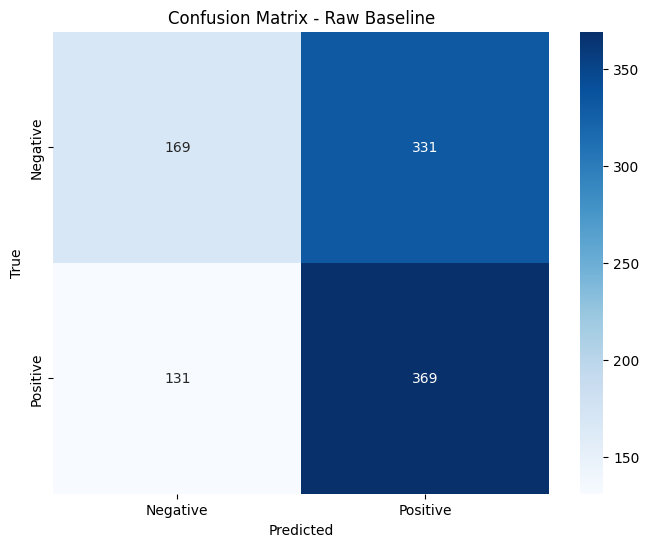

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Raw Baseline')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()